# Lab 04: GAN Training Tricks — Break It, Then Fix It

**Goal:** Deliberately cause GAN training failures, then apply tricks to fix them.

**Philosophy:** The best way to learn what breaks is to break it yourself.

**What you'll do:**
- Cause mode collapse on purpose (and fix it)
- Make D too strong (and fix it with label smoothing)
- Make D too strong (and fix it with instance noise)
- Test different learning rate combinations
- Combine all tricks and compare
- Build a diagnostic function that tells you what's wrong

**Time:** ~75 minutes

---

## Part 1: Setup — Reusable Tools

**We build 3 helper functions that we'll use throughout:**
- `make_generator()` — create a fresh DCGAN Generator
- `make_discriminator()` — create a fresh DCGAN Discriminator
- `train_gan()` — flexible trainer with knobs for every trick

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Use smaller subset for CPU training (5k instead of 60k)
if device.type == 'cpu':
    dataset = Subset(dataset, range(5000))
    print("CPU detected: using 5k image subset for speed")

dataloader = DataLoader(dataset, batch_size=64, shuffle=True)
print(f"Dataset ready: {len(dataset)} images")

Using device: cpu
CPU detected: using 5k image subset for speed
Dataset ready: 5000 images


**Factory functions — create fresh G and D for each experiment:**
- Same DCGAN architecture from Lab 03
- `noise_size` parameter lets us test different noise sizes

In [3]:
def make_generator(noise_size=100):
    return nn.Sequential(
        nn.Linear(noise_size, 256 * 7 * 7), nn.ReLU(),
        nn.Unflatten(1, (256, 7, 7)),
        nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
        nn.ConvTranspose2d(128, 1, 4, 2, 1), nn.Tanh()
    ).to(device)

def make_discriminator():
    return nn.Sequential(
        nn.Conv2d(1, 64, 4, 2, 1), nn.LeakyReLU(0.2),
        nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
        nn.Flatten(),
        nn.Linear(128 * 7 * 7, 1), nn.Sigmoid()
    ).to(device)

print("Factory functions ready.")

Factory functions ready.


**Flexible trainer — has knobs for every trick we want to test:**
- `label_smooth_real/fake` — label smoothing (default: 1.0/0.0 = off)
- `instance_noise` — noise added to images D sees (default: 0 = off)
- `d_steps/g_steps` — how many times each trains per batch
- Returns full training history for analysis

In [4]:
def train_gan(gen, dis, dataloader, epochs=10,
              lr_g=0.0002, lr_d=0.0002,
              noise_size=100,
              label_smooth_real=1.0, label_smooth_fake=0.0,
              instance_noise=0.0,
              d_steps=1, g_steps=1,
              name="GAN"):
    """
    Flexible GAN trainer with knobs for all tricks.
    Returns training history for analysis.
    """
    loss_fn = nn.BCELoss()
    g_opt = torch.optim.Adam(gen.parameters(), lr=lr_g, betas=(0.5, 0.999))
    d_opt = torch.optim.Adam(dis.parameters(), lr=lr_d, betas=(0.5, 0.999))

    history = {
        'g_loss': [], 'd_loss': [],
        'd_real': [], 'd_fake': [],
        'images': {}
    }

    fixed_noise = torch.randn(16, noise_size, device=device)

    for epoch in range(1, epochs + 1):
        eg, ed, edr, edf, nb = 0, 0, 0, 0, 0

        for real_images, _ in dataloader:
            bs = real_images.size(0)
            real = real_images.to(device)

            # Instance noise trick
            if instance_noise > 0:
                real = real + instance_noise * torch.randn_like(real)

            # Label smoothing trick
            real_labels = torch.ones(bs, 1, device=device) * label_smooth_real
            fake_labels = torch.zeros(bs, 1, device=device) + label_smooth_fake

            # Train D (d_steps times)
            for _ in range(d_steps):
                d_loss_real = loss_fn(dis(real), real_labels)
                noise = torch.randn(bs, noise_size, device=device)
                fake = gen(noise).detach()
                if instance_noise > 0:
                    fake = fake + instance_noise * torch.randn_like(fake)
                d_loss_fake = loss_fn(dis(fake), fake_labels)
                d_loss = d_loss_real + d_loss_fake
                d_opt.zero_grad(); d_loss.backward(); d_opt.step()

            # Train G (g_steps times)
            for _ in range(g_steps):
                noise = torch.randn(bs, noise_size, device=device)
                fake = gen(noise)
                g_loss = loss_fn(dis(fake), torch.ones(bs, 1, device=device))
                g_opt.zero_grad(); g_loss.backward(); g_opt.step()

            # Track
            with torch.no_grad():
                d_on_real = dis(real_images.to(device)).mean().item()
                d_on_fake = dis(gen(torch.randn(bs, noise_size, device=device))).mean().item()

            eg += g_loss.item()
            ed += d_loss.item()
            edr += d_on_real
            edf += d_on_fake
            nb += 1

        history['g_loss'].append(eg / nb)
        history['d_loss'].append(ed / nb)
        history['d_real'].append(edr / nb)
        history['d_fake'].append(edf / nb)

        # Save image snapshots
        if epoch in [1, max(1, epochs // 2), epochs]:
            gen.eval()
            with torch.no_grad():
                history['images'][epoch] = gen(fixed_noise).cpu()
            gen.train()

        if epoch % max(1, epochs // 5) == 0 or epoch == 1:
            print(f"  [{name}] Epoch {epoch:2d}: "
                  f"D={history['d_loss'][-1]:.4f} G={history['g_loss'][-1]:.4f} "
                  f"D(real)={history['d_real'][-1]:.3f} D(fake)={history['d_fake'][-1]:.3f}")

    return history

print("Trainer function ready.")

Trainer function ready.


**Comparison plotter — shows losses, D scores, and generated images for multiple experiments:**

In [5]:
def plot_comparison(results, title):
    """Plot training curves and sample images for multiple experiments."""
    n = len(results)
    fig, axes = plt.subplots(n, 4, figsize=(20, 4 * n))
    if n == 1:
        axes = axes.reshape(1, -1)

    for row, (name, hist) in enumerate(results.items()):
        # Col 0: Losses
        axes[row, 0].plot(hist['g_loss'], label='G', color='blue', linewidth=2)
        axes[row, 0].plot(hist['d_loss'], label='D', color='red', linewidth=2)
        axes[row, 0].set_title(f'{name}\nLosses', fontsize=11)
        axes[row, 0].legend(fontsize=9)
        axes[row, 0].grid(True, alpha=0.3)

        # Col 1: D scores
        axes[row, 1].plot(hist['d_real'], label='D(real)', color='green', linewidth=2)
        axes[row, 1].plot(hist['d_fake'], label='D(fake)', color='orange', linewidth=2)
        axes[row, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
        axes[row, 1].set_title('D Confidence', fontsize=11)
        axes[row, 1].legend(fontsize=9)
        axes[row, 1].set_ylim(0, 1)
        axes[row, 1].grid(True, alpha=0.3)

        # Col 2-3: Images (first and last epoch)
        epochs_saved = sorted(hist['images'].keys())
        for col_offset, ep in enumerate([epochs_saved[0], epochs_saved[-1]]):
            imgs = hist['images'][ep]
            grid = []
            for r in range(2):
                row_imgs = [imgs[r * 4 + c, 0].numpy() for c in range(4)]
                grid.append(np.concatenate(row_imgs, axis=1))
            grid = np.concatenate(grid, axis=0)
            axes[row, 2 + col_offset].imshow(grid, cmap='gray', vmin=-1, vmax=1)
            axes[row, 2 + col_offset].set_title(f'Epoch {ep}', fontsize=11)
            axes[row, 2 + col_offset].axis('off')

    plt.suptitle(title, fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

print("Plotter ready.")

Plotter ready.


---
## Part 2: Break It — Mode Collapse

**What is mode collapse?**
- G finds ONE output that fools D and keeps producing only that
- All generated images look the same — zero variety

**How to cause it:**
- Use a very small noise vector (z=2 instead of 100)
- Train G much more than D (5 G steps per 1 D step)

**We run 3 experiments:**
- Healthy baseline (z=100, balanced training)
- Collapsed (z=2, too little variety possible)
- G overtrained (5 G steps per 1 D step)

In [6]:
print("=" * 60)
print("EXPERIMENT: Causing Mode Collapse")
print("=" * 60)

print("\n--- Healthy (z=100, balanced) ---")
gen_h = make_generator(100)
dis_h = make_discriminator()
hist_healthy = train_gan(gen_h, dis_h, dataloader, epochs=5,
                         noise_size=100, name="Healthy")

print("\n--- Collapsed (z=2, too little noise) ---")
gen_c = make_generator(2)
dis_c = make_discriminator()
hist_collapsed = train_gan(gen_c, dis_c, dataloader, epochs=5,
                           noise_size=2, name="Collapsed")

print("\n--- G overtrained (5G:1D) ---")
gen_o = make_generator(100)
dis_o = make_discriminator()
hist_overtrain = train_gan(gen_o, dis_o, dataloader, epochs=5,
                           noise_size=100, d_steps=1, g_steps=5,
                           name="G-Overtrained")

EXPERIMENT: Causing Mode Collapse

--- Healthy (z=100, balanced) ---
  [Healthy] Epoch  1: D=0.1676 G=3.6604 D(real)=0.954 D(fake)=0.085
  [Healthy] Epoch  2: D=0.0374 G=5.4476 D(real)=0.987 D(fake)=0.018
  [Healthy] Epoch  3: D=0.1619 G=5.7233 D(real)=0.954 D(fake)=0.052
  [Healthy] Epoch  4: D=0.2717 G=4.2710 D(real)=0.893 D(fake)=0.109
  [Healthy] Epoch  5: D=0.5477 G=2.0318 D(real)=0.780 D(fake)=0.214

--- Collapsed (z=2, too little noise) ---
  [Collapsed] Epoch  1: D=1.2082 G=1.2791 D(real)=0.633 D(fake)=0.477
  [Collapsed] Epoch  2: D=0.9287 G=1.3517 D(real)=0.647 D(fake)=0.357
  [Collapsed] Epoch  3: D=0.7649 G=1.5017 D(real)=0.704 D(fake)=0.303
  [Collapsed] Epoch  4: D=0.6217 G=1.7252 D(real)=0.759 D(fake)=0.256
  [Collapsed] Epoch  5: D=0.6304 G=1.8134 D(real)=0.759 D(fake)=0.246

--- G overtrained (5G:1D) ---
  [G-Overtrained] Epoch  1: D=0.3988 G=2.4417 D(real)=0.895 D(fake)=0.189
  [G-Overtrained] Epoch  2: D=1.1469 G=1.4085 D(real)=0.621 D(fake)=0.376
  [G-Overtrained] E

**Compare all 3:**
- Look at the images (col 3-4): collapsed ones all look the same
- Look at D scores (col 2): collapsed G might have low D(fake) but no variety

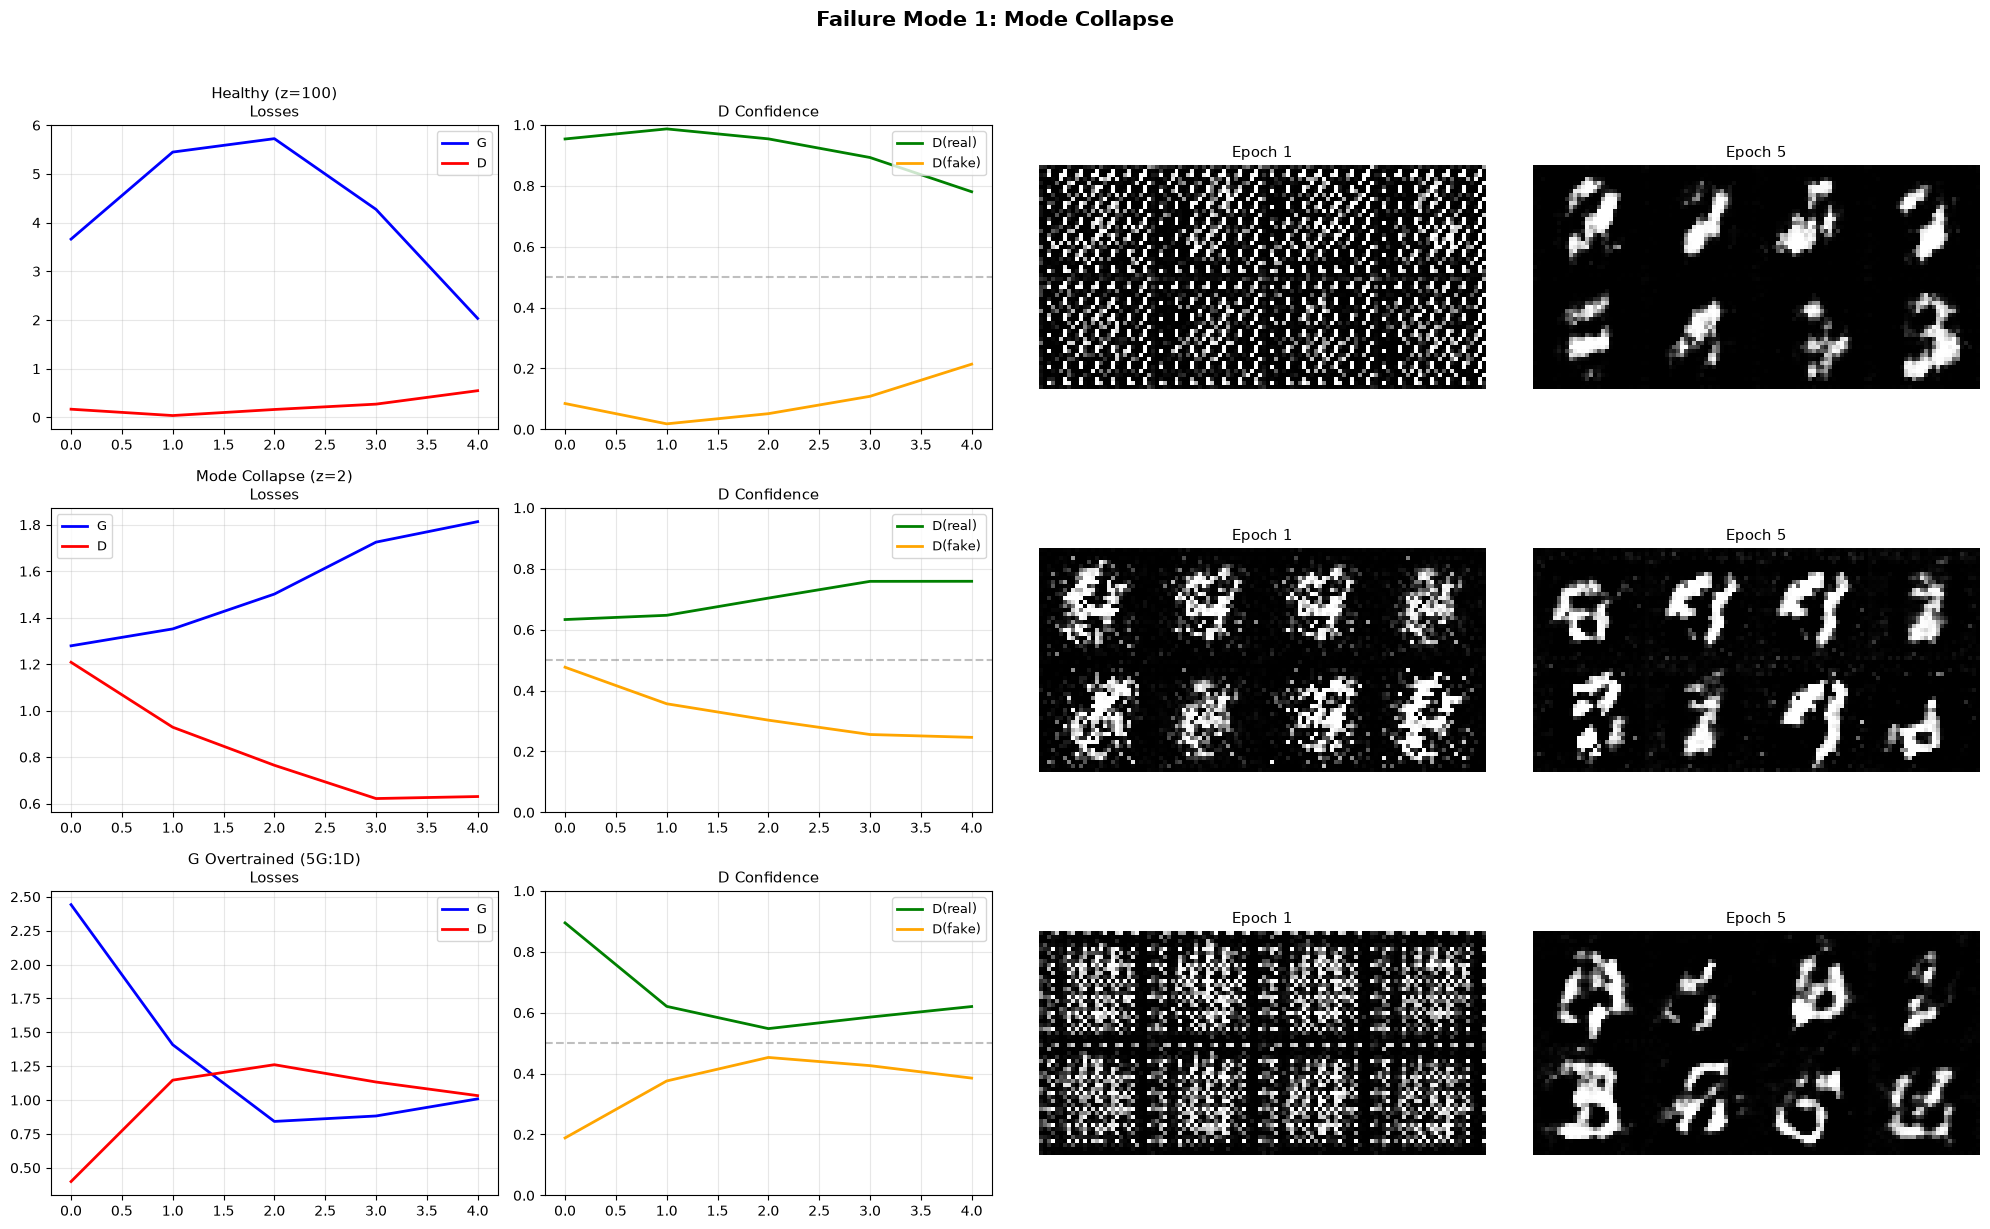

In [7]:
plot_comparison({
    'Healthy (z=100)': hist_healthy,
    'Mode Collapse (z=2)': hist_collapsed,
    'G Overtrained (5G:1D)': hist_overtrain,
}, title='Failure Mode 1: Mode Collapse')

**Diversity score — measure how different the generated images are:**
- Higher = more variety (good)
- Lower = all images look the same (mode collapse!)

In [8]:
def diversity_score(generator, noise_size, n=100):
    generator.eval()
    with torch.no_grad():
        imgs = generator(torch.randn(n, noise_size, device=device)).cpu().view(n, -1)
    generator.train()
    dists = torch.cdist(imgs, imgs)
    mask = torch.triu(torch.ones(n, n, dtype=torch.bool), diagonal=1)
    return dists[mask].mean().item()

print("Diversity scores (higher = more variety):")
print(f"  Healthy (z=100):     {diversity_score(gen_h, 100):.4f}")
print(f"  Collapsed (z=2):     {diversity_score(gen_c, 2):.4f}")
print(f"  G-Overtrained:       {diversity_score(gen_o, 100):.4f}")
print("\nLow diversity = mode collapse.")

Diversity scores (higher = more variety):
  Healthy (z=100):     18.2596
  Collapsed (z=2):     16.6472
  G-Overtrained:       19.3846

Low diversity = mode collapse.


**Takeaway:**

| Cause | Fix |
|---|---|
| Noise vector too small | Use z=100 or z=128 |
| G trains much more than D | Keep 1:1 ratio |
| Poor loss function | Use WGAN loss (Phase 2) |

---

## Part 3: Break It — D Wins Too Easily

**What happens:** D becomes too strong, outputs 0.000 for all fakes. G gets zero gradient.

**How to cause it:**
- Give D a much higher learning rate (lr_d=0.01)
- Train D 5 times per G step

**What to watch:**
- D_loss drops to ~0 (D is perfect)
- G_loss stays high (G is stuck)
- D(fake) drops to ~0 (D catches everything)
- Images don't improve

In [ ]:
print("=" * 60)
print("EXPERIMENT: D Wins Too Easily")
print("=" * 60)

print("\n--- D too strong (lr_d=0.01, 100x faster than G) ---")
gen_ds = make_generator()
dis_ds = make_discriminator()
hist_d_strong = train_gan(gen_ds, dis_ds, dataloader, epochs=5,
                          lr_g=0.0002, lr_d=0.01, name="D-TooStrong")

print("\n--- D overtrained (5D:1G) ---")
gen_do = make_generator()
dis_do = make_discriminator()
hist_d_over = train_gan(gen_do, dis_do, dataloader, epochs=5,
                        d_steps=5, g_steps=1, name="D-Overtrained")

**Compare with the healthy baseline:**

In [ ]:
plot_comparison({
    'Healthy': hist_healthy,
    'D too strong (lr=0.01)': hist_d_strong,
    'D overtrained (5D:1G)': hist_d_over,
}, title='Failure Mode 2: D Wins Too Easily')

**Takeaway:**

| Symptom | What's happening |
|---|---|
| D_loss near 0 | D classifies everything perfectly |
| G_loss stays high | G gets no useful gradient |
| D(fake) near 0 | D catches every fake with 100% confidence |

Now let's fix it with 3 different tricks.

---

## Part 4: Fix 1 — Label Smoothing

**The idea:**
- Instead of real=1.0, fake=0.0, use real=0.9, fake=0.1
- D can never be more than 90% confident
- This caps D's strength and keeps gradients flowing to G

**We test:** same broken setup (D lr=0.01) but with label smoothing

In [ ]:
print("=" * 60)
print("FIX 1: Label Smoothing")
print("=" * 60)

print("\n--- Broken: D too strong (lr_d=0.01) ---")
gen_b = make_generator()
dis_b = make_discriminator()
hist_broken = train_gan(gen_b, dis_b, dataloader, epochs=5,
                        lr_g=0.0002, lr_d=0.01, name="Broken")

print("\n--- Fixed: + Label smoothing (real=0.9, fake=0.1) ---")
gen_ls = make_generator()
dis_ls = make_discriminator()
hist_smooth = train_gan(gen_ls, dis_ls, dataloader, epochs=5,
                        lr_g=0.0002, lr_d=0.01,
                        label_smooth_real=0.9, label_smooth_fake=0.1,
                        name="Label-Smoothed")

In [ ]:
plot_comparison({
    'Broken (D too strong)': hist_broken,
    'Fixed (Label Smoothing)': hist_smooth,
}, title='Fix 1: Label Smoothing')

**How label smoothing works:**
```
Without:  D targets = [1.0, 0.0]  --> D can be 100% confident
With:     D targets = [0.9, 0.1]  --> D can never be >90% confident

Result: D's confidence is capped, gradients keep flowing to G
```

---

## Part 5: Fix 2 — Instance Noise

**The idea:**
- Add random noise to the images D sees
- Like making D wear foggy glasses
- D's job becomes harder → can't dominate G

**First, let's see what instance noise looks like:**

In [ ]:
sample_img = dataset[0][0]
noise_levels = [0.0, 0.05, 0.1, 0.2, 0.5]

fig, axes = plt.subplots(1, len(noise_levels), figsize=(15, 3))
for ax, sigma in zip(axes, noise_levels):
    noisy = sample_img + sigma * torch.randn_like(sample_img)
    ax.imshow(noisy[0], cmap='gray')
    ax.set_title(f'noise={sigma}', fontsize=11)
    ax.axis('off')

plt.suptitle('Instance Noise: what D sees at different noise levels',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("0.05-0.1 is the sweet spot. 0.5 is too much.")

**Now test: same broken setup but with instance noise:**

In [ ]:
print("=" * 60)
print("FIX 2: Instance Noise")
print("=" * 60)

print("\n--- Fixed: + Instance noise (sigma=0.1) ---")
gen_in = make_generator()
dis_in = make_discriminator()
hist_noisy = train_gan(gen_in, dis_in, dataloader, epochs=5,
                       lr_g=0.0002, lr_d=0.01,
                       instance_noise=0.1, name="Instance-Noise")

In [ ]:
plot_comparison({
    'Broken (D too strong)': hist_broken,
    'Fixed (Instance Noise)': hist_noisy,
}, title='Fix 2: Instance Noise')

---
## Part 6: Fix 3 — Learning Rate Balance

**The #1 most important trick in GAN training:**
- Balanced = stable
- D too fast = D dominates, G stuck
- G too fast = G cheats
- Slow D = D can't dominate (intentional handicap)

**We test 4 combinations:**

In [ ]:
print("=" * 60)
print("FIX 3: Learning Rate Balance")
print("=" * 60)

lr_experiments = {
    'Balanced (0.0002/0.0002)': (0.0002, 0.0002),
    'D too fast (0.0002/0.002)': (0.0002, 0.002),
    'G too fast (0.002/0.0002)': (0.002, 0.0002),
    'Slow D fix (0.0002/0.0001)': (0.0002, 0.0001),
}

lr_results = {}
for name, (lr_g, lr_d) in lr_experiments.items():
    print(f"\n--- {name} ---")
    g = make_generator()
    d = make_discriminator()
    lr_results[name] = train_gan(g, d, dataloader, epochs=5,
                                 lr_g=lr_g, lr_d=lr_d, name=name)

In [ ]:
plot_comparison(lr_results, title='Fix 3: Learning Rate Balance')

**What to notice:**
- **Balanced:** stable training, good images
- **D too fast:** D dominates, G stuck
- **G too fast:** G cheats, possible mode collapse
- **Slow D:** D can't dominate, G gets better signal

**Rule of thumb:** if training is unstable, lower D's learning rate first.

---

## Part 7: Combine All Tricks

**In practice, you combine tricks. Let's see the effect:**
- No tricks vs all tricks (label smoothing + instance noise + balanced LR)

In [ ]:
print("=" * 60)
print("COMBINED TRICKS")
print("=" * 60)

print("\n--- No tricks ---")
gen_none = make_generator()
dis_none = make_discriminator()
hist_none = train_gan(gen_none, dis_none, dataloader, epochs=8,
                      name="No tricks")

print("\n--- All tricks combined ---")
gen_all = make_generator()
dis_all = make_discriminator()
hist_all = train_gan(gen_all, dis_all, dataloader, epochs=8,
                     label_smooth_real=0.9, label_smooth_fake=0.1,
                     instance_noise=0.05,
                     name="All tricks")

In [ ]:
plot_comparison({
    'No Tricks': hist_none,
    'All Tricks Combined': hist_all,
}, title='Combined Effect of All Tricks')

---
## Part 8: Diagnostic Function

**In real projects, you want automatic diagnosis.**
- Feed it training history
- It tells you what's wrong and suggests fixes

In [ ]:
def diagnose(history, name):
    g = history['g_loss']
    d = history['d_loss']
    dr = history['d_real']
    df = history['d_fake']

    print(f"\n{'=' * 50}")
    print(f"DIAGNOSIS: {name}")
    print(f"{'=' * 50}")

    if d[-1] < 0.1:
        print("[WARNING] D_loss near 0 -- D is dominating!")
        print("  Fix: lower D lr, add label smoothing")
    if g[-1] > 5.0:
        print("[WARNING] G_loss very high -- G is stuck!")
        print("  Fix: lower D lr, add instance noise")
    if dr[-1] > 0.95:
        print("[WARNING] D(real) > 0.95 -- D too confident on real")
        print("  Fix: label smoothing (real=0.9)")
    if df[-1] < 0.05:
        print("[WARNING] D(fake) < 0.05 -- D catches everything")
        print("  Fix: instance noise, lower D lr")

    g_std = np.std(g[-5:])
    if g[-1] < 1.0 and g_std < 0.05:
        print("[WARNING] G_loss low and flat -- possible mode collapse")
        print("  Fix: increase noise size, check image variety")

    d_changes = [abs(d[i] - d[i-1]) for i in range(1, len(d))]
    if len(d_changes) > 0 and np.mean(d_changes) > 0.5:
        print("[WARNING] Large loss swings -- training is oscillating")
        print("  Fix: lower learning rate")

    if 0.3 < dr[-1] < 0.9 and 0.1 < df[-1] < 0.7:
        print("[OK] D confidence looks balanced")
    if abs(g[-1] - d[-1]) < 1.0:
        print("[OK] G and D losses are roughly balanced")

    print(f"\n  Final: G_loss={g[-1]:.4f} D_loss={d[-1]:.4f}")
    print(f"  D(real)={dr[-1]:.3f}  D(fake)={df[-1]:.3f}")

**Run diagnosis on our experiments:**

In [ ]:
diagnose(hist_healthy, "Healthy Baseline")
diagnose(hist_d_strong, "D Too Strong")
diagnose(hist_collapsed, "Mode Collapse (z=2)")
diagnose(hist_all, "All Tricks Combined")

---
## Part 9: Challenge — Fix a Broken GAN

**Here's a deliberately broken GAN. Your job: diagnose and fix it.**

The broken settings:
- G learning rate is 100x slower than D
- D trains 3x more than G
- No tricks applied

**Step 1:** Run the broken version and look at the diagnosis

In [ ]:
print("--- BROKEN GAN ---")
gen_broken = make_generator()
dis_broken = make_discriminator()
hist_challenge = train_gan(
    gen_broken, dis_broken, dataloader, epochs=5,
    lr_g=0.00005, lr_d=0.005,
    d_steps=3, g_steps=1,
    name="BROKEN"
)
diagnose(hist_challenge, "Broken Challenge")

**Step 2: Fix it!**
- Look at the diagnosis warnings
- Adjust the settings below
- Hint: fix the learning rates, fix the D:G ratio, add tricks

In [ ]:
print("--- YOUR FIX ---")
gen_fixed = make_generator()
dis_fixed = make_discriminator()
hist_fixed = train_gan(
    gen_fixed, dis_fixed, dataloader, epochs=5,
    lr_g=0.0002,              # TODO: adjust this
    lr_d=0.0002,              # TODO: adjust this
    d_steps=1,                # TODO: adjust this
    g_steps=1,
    label_smooth_real=0.9,    # TODO: try label smoothing
    label_smooth_fake=0.1,
    name="YOUR FIX"
)
diagnose(hist_fixed, "Your Fix")

**Compare broken vs your fix:**

In [ ]:
plot_comparison({
    'BROKEN': hist_challenge,
    'YOUR FIX': hist_fixed,
}, title='Challenge: Can You Fix the Broken GAN?')

---
## Part 10: The GAN Training Checklist

```
+──────────────────────────────────────────────────────+
│              GAN TRAINING CHECKLIST                    │
│                                                        │
│  DATA                                                  │
│  [ ] Normalize images to [-1, 1]                       │
│  [ ] Shuffle dataset                                   │
│                                                        │
│  ARCHITECTURE                                          │
│  [ ] G output: Tanh                                    │
│  [ ] G hidden: ReLU                                    │
│  [ ] D hidden: LeakyReLU(0.2)                          │
│  [ ] D output: Sigmoid                                 │
│  [ ] BatchNorm in both (NOT D's first layer)           │
│                                                        │
│  TRAINING                                              │
│  [ ] Adam: lr=0.0002, betas=(0.5, 0.999)               │
│  [ ] Label smoothing: real=0.9, fake=0.1               │
│  [ ] D and G train same steps (1:1)                    │
│  [ ] .detach() when training D                         │
│                                                        │
│  MONITORING                                            │
│  [ ] Track D_loss and G_loss                           │
│  [ ] Track D(real) and D(fake)                         │
│  [ ] Save images every N epochs                        │
│  [ ] Check variety (not all same)                      │
│                                                        │
│  IF STUCK                                              │
│  [ ] D too strong? Lower D lr, label smoothing         │
│  [ ] Mode collapse? Increase z, check D:G ratio        │
│  [ ] Oscillating? Lower both lr                        │
+──────────────────────────────────────────────────────+
```

---
## Part 11: Summary

| What you did | What you learned |
|---|---|
| Caused mode collapse (z=2) | Small noise = no variety |
| Caused mode collapse (5G:1D) | Overtraining G = G cheats |
| Caused D domination (high D lr) | D too fast = G gets no gradient |
| Fixed with label smoothing | Caps D confidence at 90% |
| Fixed with instance noise | Foggy glasses for D |
| Fixed with LR balance | Most important setting |
| Combined all tricks | Better than any single fix |
| Built diagnostic function | Auto-detect problems |
| Fixed a broken GAN yourself | Applied everything you learned |

**Phase 1 complete!** You can now build, train, and debug GANs.

**Next phase:** WGAN replaces BCE loss with Wasserstein distance — a fundamentally better way to train GANs that avoids many of these problems at the root.